In [21]:
from PVGeo.grids import SurferGridReader

fname = "/mnt/Garbage/Андрей/sochi/tomo_p_res.grd"
dem = SurferGridReader().apply(fname)
print(dem)

ImageData (0x78fb9ccbed40)
  N Cells:      568632
  N Points:     570251
  X Bounds:     0.000e+00, 1.102e+03
  Y Bounds:     -3.640e+02, 1.520e+02
  Z Bounds:     0.000e+00, 0.000e+00
  Dimensions:   1103, 517, 1
  Spacing:      1.000e+00, 1.000e+00, 1.000e+00
  N Arrays:     1


In [22]:
import numpy as np
vp = dem.active_scalars

# Reshape to 2D grid (rows, cols)
n_rows = dem.dimensions[1]  # 259
n_cols = dem.dimensions[0]  # 443
vp_2d = np.flip(vp.reshape(n_rows, n_cols)).T
# vp_2d[np.isnan(vp_2d)] = 0.
print(vp_2d.shape)  # (259, 443)
print(vp_2d)

(1103, 517)
[[       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ... 3.52268477 3.52452734 3.5263482 ]
 [       nan        nan        nan ... 3.52320961 3.52504099 3.52688333]
 ...
 [       nan        nan        nan ... 3.54926717 3.55110058 3.55293398]
 [       nan        nan        nan ... 3.54804686 3.54988026 3.55171373]
 [       nan        nan        nan ... 3.54682678 3.54866018 3.55049358]]


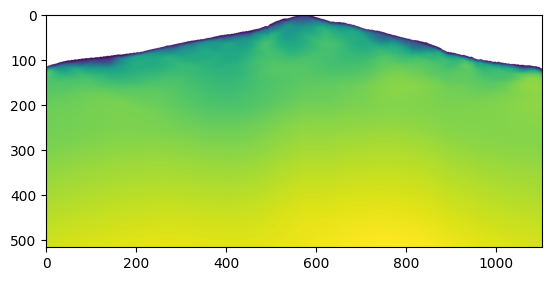

In [23]:
from matplotlib import pyplot as plt

plt.imshow(vp_2d.T)
plt.show()

In [24]:
np.quantile(vp_2d[~np.isnan(vp_2d)], 0.0005)

np.float64(0.39013090629013175)

In [30]:
f_max = 0.1
print(np.min(vp_2d[~np.isnan(vp_2d)]) / (10 * 0.03))

1.0760044549428074


In [4]:
import segyio
from examples.seismic.fwi.seg_util import get_headers

header_list = [
    segyio.TraceField.SourceX,
    segyio.TraceField.SourceY,
    segyio.TraceField.SourceSurfaceElevation ,
    segyio.TraceField.GroupX,
    segyio.TraceField.GroupY,
    segyio.TraceField.ReceiverGroupElevation ,
    segyio.TraceField.SourceGroupScalar,
    segyio.TraceField.ElevationScalar
]

remap_string = "rec_sloc,4R,IBM,197 / sou_sloc,4R,IBM,201"
data_path = "/mnt/Ngen_3/2026.02 - (183) Сочи/040 - Обработка/FWI/data_unprocessed.sgy"
with segyio.open(data_path, "r", ignore_geometry=True) as f:
    hdr = get_headers(f, header_list, remap_string)
for key in ['SourceX', 'SourceY', 'SourceSurfaceElevation', 'GroupX','GroupY', 'ReceiverGroupElevation']:
    hdr[key] = hdr[key] / 100
print(hdr)

{'SourceX': array([553492.64, 553502.02, 553511.71, ..., 554020.06, 554030.46,
       554066.43], shape=(11612,)), 'SourceY': array([4835991.9 , 4835989.15, 4835987.25, ..., 4835877.55, 4835874.63,
       4835869.32], shape=(11612,)), 'SourceSurfaceElevation': array([149.42, 152.55, 152.8 , ...,  49.1 ,  46.83,  36.09],
      shape=(11612,)), 'GroupX': array([552988.44, 552988.44, 552988.44, ..., 554064.19, 554064.19,
       554064.19], shape=(11612,)), 'GroupY': array([4836099.8 , 4836099.8 , 4836099.8 , ..., 4835868.44, 4835868.44,
       4835868.44], shape=(11612,)), 'ReceiverGroupElevation': array([31.3 , 31.3 , 31.3 , ..., 36.58, 36.58, 36.58], shape=(11612,)), 'SourceGroupScalar': array([-100, -100, -100, ..., -100, -100, -100],
      shape=(11612,), dtype=int32), 'ElevationScalar': array([-100, -100, -100, ..., -100, -100, -100],
      shape=(11612,), dtype=int32), 'rec_sloc': array([  5.,   5.,   5., ..., 225., 225., 225.], shape=(11612,)), 'sou_sloc': array([108., 110., 112., 

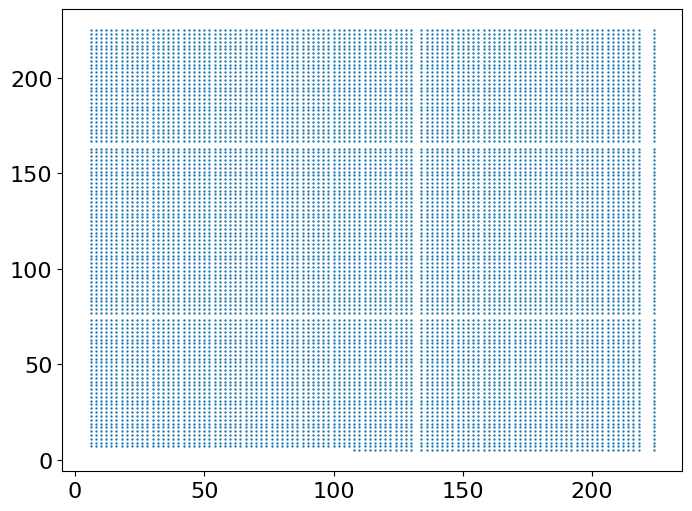

In [5]:
from matplotlib import pyplot as plt
plt.scatter(hdr['sou_sloc'], hdr['rec_sloc'], s=0.5)
plt.show()